# Qwen3-VL-4B-Instruct 교통사고 QA LoRA 미세조정

**실행 순서**: 위에서 아래로 순서대로 셀을 실행하세요.  
**핵심 수정 섹션**: `Section 4. 학습 설정` — 여기서 하이퍼파라미터를 바꾸세요.

---
| GPU | 권장 설정 |
|-----|----------|
| A100 (40GB) | bf16=True, fps=1.0, max_pixels=360×420 |
| T4 (16GB)   | fp16=True, fps=0.5, max_pixels=320×320 |


## Section 0. 환경 감지 및 경로 설정

Colab / 로컬 모두 이 셀 하나로 환경을 설정합니다.  
**로컬 실행 시**: `LOCAL_REPO_ROOT` 를 레포 루트 절대 경로로 수정하세요.  
**Colab 실행 시**: `COLAB_REPO_ROOT` 를 Drive 내 레포 경로로 수정하세요.

In [1]:
import sys
from pathlib import Path

# ── 경로 직접 지정 ────────────────────────────────────────────────────────
LOCAL_REPO_ROOT = Path("/Users/shimsomin/Workplace/git_workspace/traffic-fault-platform")
COLAB_REPO_ROOT = Path("/content/drive/MyDrive/멋쟁이사자처럼/traffic-fault-platform")

# ── 환경 감지 ─────────────────────────────────────────────────────────────
try:
    import google.colab
    IS_COLAB = True
except ImportError:
    IS_COLAB = False

print(f"실행 환경: {'Google Colab' if IS_COLAB else '로컬'}")

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    REPO_ROOT = COLAB_REPO_ROOT
else:
    REPO_ROOT = LOCAL_REPO_ROOT
    # 로컬: pip install 없이 sys.path에 src 경로 직접 추가
    for src in [
        REPO_ROOT / "apps/training-runner/src",
        REPO_ROOT / "packages/ai-core/src",
    ]:
        if str(src) not in sys.path and src.exists():
            sys.path.insert(0, str(src))
            print(f"sys.path 추가: {src}")

# ── 데이터 경로 ───────────────────────────────────────────────────────────
QA_JSON_PATH   = REPO_ROOT / "data/qa/qa_dataset.json"
RAW_VIDEO_ROOT = REPO_ROOT / "data/working/pipeline_subset/raw"
LABEL_ROOT     = REPO_ROOT / "data/working/pipeline_subset/label"
CHECKPOINT_DIR = REPO_ROOT / "checkpoints/Qwen3_VL_4B_Instruct"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print(f"\nREPO_ROOT: {REPO_ROOT}")
for name, p in [("QA JSON", QA_JSON_PATH), ("Raw 비디오", RAW_VIDEO_ROOT), ("Label", LABEL_ROOT)]:
    print(f"  {'✓' if p.exists() else '✗ 없음!'} {name}: {p}")

실행 환경: Google Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

REPO_ROOT: /content/drive/MyDrive/멋쟁이사자처럼/traffic-fault-platform
  ✓ QA JSON: /content/drive/MyDrive/멋쟁이사자처럼/traffic-fault-platform/data/qa/qa_dataset.json
  ✓ Raw 비디오: /content/drive/MyDrive/멋쟁이사자처럼/traffic-fault-platform/data/working/pipeline_subset/raw
  ✓ Label: /content/drive/MyDrive/멋쟁이사자처럼/traffic-fault-platform/data/working/pipeline_subset/label


## Section 1. 패키지 설치

- **Colab**: 아래 셀을 실행하세요 (런타임 재시작이 필요할 수 있습니다)
- **로컬**: Section 0에서 sys.path를 추가했으므로 이 셀은 건너뛰어도 됩니다  
  (단, `pip install qwen-vl-utils peft accelerate transformers av` 는 미리 설치되어 있어야 합니다)

In [2]:
!pip install qwen-vl-utils peft accelerate transformers av

In [3]:
if IS_COLAB:
    import subprocess

    # 외부 패키지 설치
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
        "transformers>=4.51.0", "peft>=0.11.0", "qwen-vl-utils>=0.0.8",
        "accelerate>=0.30.0", "av", "matplotlib", "seaborn"], check=True)

    # 로컬 패키지 설치
    for pkg_path in [
        REPO_ROOT / "packages/ai-core",
        REPO_ROOT / "apps/training-runner",
    ]:
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", "-e", str(pkg_path), "-q"],
            capture_output=True, text=True
        )
        print(f"{pkg_path.name}: {'✓' if result.returncode == 0 else result.stderr}")
else:
    print("로컬 환경 — sys.path가 Section 0에서 이미 설정됨. 설치 생략.")

ai-core: ✓
training-runner: ✓


## Section 2. GPU 환경 확인

In [4]:
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU  : {gpu_name}")
    print(f"VRAM : {vram_gb:.1f} GB")

    if vram_gb >= 35:
        print("→ A100 감지: bf16=True, fps=1.0 권장")
        RECOMMENDED_BF16, RECOMMENDED_FP16 = True, False
        RECOMMENDED_FPS, RECOMMENDED_MAX_PIXELS = 1.0, 360 * 420
    else:
        print("→ T4/V100 감지: fp16=True, fps=0.5 권장 (메모리 절약)")
        RECOMMENDED_BF16, RECOMMENDED_FP16 = False, True
        RECOMMENDED_FPS, RECOMMENDED_MAX_PIXELS = 0.5, 320 * 320
else:
    print("GPU 없음 (CPU 실행 — 디버깅 전용)")
    RECOMMENDED_BF16, RECOMMENDED_FP16 = False, False
    RECOMMENDED_FPS, RECOMMENDED_MAX_PIXELS = 0.5, 320 * 320

GPU  : NVIDIA A100-SXM4-40GB
VRAM : 42.4 GB
→ A100 감지: bf16=True, fps=1.0 권장


## Section 3. 데이터 확인 및 분포 시각화

In [ ]:
import json
from collections import Counter

with open(QA_JSON_PATH, encoding="utf-8") as f:
    qa_data = json.load(f)

print(f"QA 항목 수  : {len(qa_data)}")
print(f"QA쌍 / 항목 : {len(qa_data[0]['qa_pairs'])}")
print(f"최대 샘플 수: {len(qa_data) * len(qa_data[0]['qa_pairs'])}")

# 3방향 매칭 확인
raw_mp4s    = list(RAW_VIDEO_ROOT.rglob("*.mp4"))
label_jsons = list(LABEL_ROOT.rglob("*.json"))
raw_stems   = {p.stem for p in raw_mp4s}
label_stems = {p.stem for p in label_jsons}
qa_stems    = {Path(e['video_id']).stem for e in qa_data}
matched     = qa_stems & raw_stems & label_stems

print(f"\nRaw 비디오 : {len(raw_mp4s)}개")
print(f"Label JSON : {len(label_jsons)}개")
print(f"QA 항목    : {len(qa_data)}개")
print(f"3방향 매칭 : {len(matched)}개  → 학습 샘플: {len(matched) * 6}개")

QA 항목 수  : 80
QA쌍 / 항목 : 6
최대 샘플 수: 480

Raw 비디오 : 80개
Label JSON : 80개
QA 항목    : 80개
3방향 매칭 : 80개  → 학습 샘플: 480개


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 한글 폰트 설정 (Colab)
if IS_COLAB:
    import subprocess
    subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], capture_output=True)
    fm._load_fontmanager(try_read_cache=False)
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

cat_counter    = Counter(p.parent.name for p in raw_mp4s)
label_map_plot = {p.stem: p.parent.name for p in label_jsons}
qa_cat_counter = Counter(
    label_map_plot[Path(e['video_id']).stem]
    for e in qa_data if Path(e['video_id']).stem in label_map_plot
)
qt_counter = Counter(
    qa['question_type'] for e in qa_data for qa in e['qa_pairs']
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 카테고리별 비디오 수
cats = sorted(cat_counter)
b = axes[0].barh(cats, [cat_counter[c] for c in cats], color=sns.color_palette("Blues_d", len(cats)))
axes[0].bar_label(b, fmt='%d개', padding=3)
axes[0].set_title("카테고리별 비디오 수")

# 카테고리별 QA 항목 수
qcats = sorted(qa_cat_counter)
b2 = axes[1].barh(qcats, [qa_cat_counter[c] for c in qcats], color=sns.color_palette("Oranges_d", len(qcats)))
axes[1].bar_label(b2, fmt='%d개', padding=3)
axes[1].set_title("카테고리별 QA 항목 수")

# 질문 유형별 분포
types = list(qt_counter)
b3 = axes[2].bar(types, [qt_counter[t] for t in types], color=sns.color_palette("Greens_d", len(types)))
axes[2].bar_label(b3, fmt='%d개', padding=3)
axes[2].set_title("질문 유형별 분포")
plt.setp(axes[2].get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

## Section 4. 학습 설정

실험 포인트는 `TRAINING_NOTES.md` 참고.

In [ ]:
torchvision_version = torch.__version__

In [14]:
from training_runner.train import TrainingConfig

config = TrainingConfig(
    qa_json_path   = str(QA_JSON_PATH),
    raw_video_root = str(RAW_VIDEO_ROOT),
    label_root     = str(LABEL_ROOT),
    checkpoint_dir = str(CHECKPOINT_DIR),

    model_id = "Qwen/Qwen3-VL-4B-Instruct",

    # LoRA
    lora_r       = 16,
    lora_alpha   = 32,
    lora_dropout = 0.05,

    # 학습
    num_train_epochs            = 5,
    learning_rate               = 2e-4,
    per_device_train_batch_size = 1,
    gradient_accumulation_steps = 4,
    lr_scheduler_type           = "cosine",

    # 비디오
    fps        = RECOMMENDED_FPS,
    max_pixels = RECOMMENDED_MAX_PIXELS,
    max_seq_len = 512,

    # 정밀도
    bf16 = RECOMMENDED_BF16,
    fp16 = RECOMMENDED_FP16,

    train_ratio    =  0.75 # 60:20 # 0.875 = 70:10
    seed           = 42,
    question_types = None,  # None = 전체 6종류
    report_to      = "none",
    dataloader_num_workers   = 4 #8
)

print(f"fps={config.fps}, max_pixels={config.max_pixels}")
print(f"lora_r={config.lora_r}, lr={config.learning_rate}, epochs={config.num_train_epochs}")
print(f"bf16={config.bf16}, fp16={config.fp16}")
print(f"dataloader_num_workers={config.dataloader_num_workers}")

fps=1.0, max_pixels=151200
lora_r=16, lr=0.0002, epochs=5
bf16=True, fp16=False
dataloader_num_workers=4


## Section 5. 데이터셋 구성 및 분포 확인

In [15]:
from transformers import AutoProcessor
from training_runner.dataset import build_dataloaders

print("프로세서 로드 중...")
processor = AutoProcessor.from_pretrained(config.model_id)

print("데이터셋 구성 중 (QA ↔ 비디오 매칭)...")
train_ds, val_ds, _, _ = build_dataloaders(
    qa_json_path   = config.qa_json_path,
    raw_video_root = config.raw_video_root,
    label_root     = config.label_root,
    processor      = processor,
    train_ratio    = config.train_ratio,
    seed           = config.seed,
    fps            = config.fps,
    max_pixels     = config.max_pixels,
    max_seq_len    = config.max_seq_len,
    question_types = config.question_types,
)

print(f"\n학습 샘플: {len(train_ds)}개")
print(f"검증 샘플: {len(val_ds)}개")

프로세서 로드 중...
데이터셋 구성 중 (QA ↔ 비디오 매칭)...
[Dataset._build_index] QA: 80 | 매칭: 80 | 미매칭: 0 | 샘플: 480
[Dataset] 활성 샘플 수: 480 (전체 매칭: 480)
[build_dataloaders] 학습: 70개 비디오 / 420샘플 | 검증: 10개 비디오 / 60샘플
[Dataset._build_index] QA: 80 | 매칭: 80 | 미매칭: 0 | 샘플: 480
[Dataset] 활성 샘플 수: 420 (전체 매칭: 480)
[Dataset._build_index] QA: 80 | 매칭: 80 | 미매칭: 0 | 샘플: 480
[Dataset] 활성 샘플 수: 60 (전체 매칭: 480)

학습 샘플: 420개
검증 샘플: 60개


In [16]:
import matplotlib.pyplot as plt

/tmp/ipykernel_1855/3066170695.py:16: UserWarning: Glyph 4364 (\N{HANGUL CHOSEONG CIEUC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1855/3066170695.py:16: UserWarning: Glyph 4449 (\N{HANGUL JUNGSEONG A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1855/3066170695.py:16: UserWarning: Glyph 4370 (\N{HANGUL CHOSEONG HIEUH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1855/3066170695.py:16: UserWarning: Glyph 4455 (\N{HANGUL JUNGSEONG YEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1855/3066170695.py:16: UserWarning: Glyph 4540 (\N{HANGUL JONGSEONG IEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1855/3066170695.py:16: UserWarning: Glyph 4352 (\N{HANGUL CHOSEONG KIYEOK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1855/3066170695.py:16: UserWarning: Glyph 4461 (\N{HANGUL JUNGSEONG YO}) missing from font(s) DejaVu Sans.
  plt.tigh

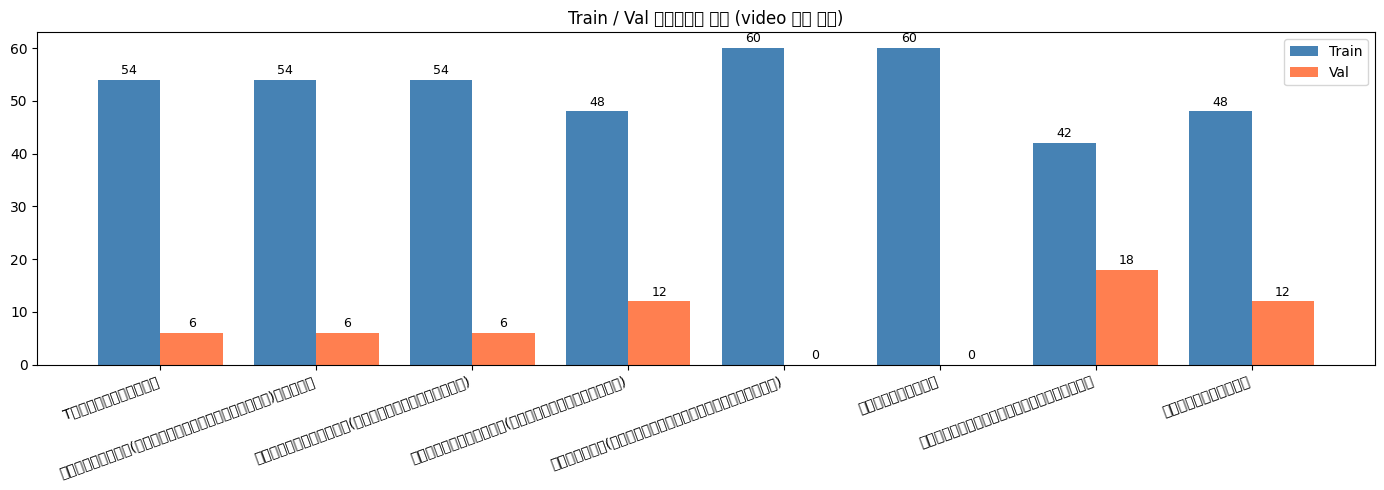

Train: 420샘플 (70개 비디오)
Val  : 60샘플 (10개 비디오)


In [17]:
# Train / Val 카테고리 분포
train_dist = train_ds.get_distribution()
val_dist   = val_ds.get_distribution()
all_cats   = sorted(set(train_dist['by_category']) | set(val_dist['by_category']))
x, w = range(len(all_cats)), 0.4

fig, ax = plt.subplots(figsize=(14, 5))
b1 = ax.bar([i - w/2 for i in x], [train_dist['by_category'].get(c, 0) for c in all_cats], width=w, label='Train', color='steelblue')
b2 = ax.bar([i + w/2 for i in x], [val_dist['by_category'].get(c, 0) for c in all_cats],   width=w, label='Val',   color='coral')
ax.bar_label(b1, fmt='%d', padding=2, fontsize=9)
ax.bar_label(b2, fmt='%d', padding=2, fontsize=9)
ax.set_xticks(list(x))
ax.set_xticklabels(all_cats, rotation=20, ha='right')
ax.set_title("Train / Val 카테고리별 분포 (video 단위 분할)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Train: {train_dist['total']}샘플 ({train_dist['unique_videos']}개 비디오)")
print(f"Val  : {val_dist['total']}샘플 ({val_dist['unique_videos']}개 비디오)")

In [18]:
# 샘플 1개 레이블 마스킹 확인
sample      = train_ds[0]
input_ids   = sample['input_ids']
labels      = sample['labels']
answer_mask = labels != -100

print(f"전체 시퀀스 길이 : {len(input_ids)} 토큰")
print(f"마스킹 구간      : {(~answer_mask).sum().item()} 토큰 (-100)")
print(f"답변 구간        : {answer_mask.sum().item()} 토큰")
print(f"디코딩된 답변    : {processor.tokenizer.decode(input_ids[answer_mask], skip_special_tokens=True)!r}")

전체 시퀀스 길이 : 394 토큰
마스킹 구간      : 386 토큰 (-100)
답변 구간        : 8 토큰
디코딩된 답변    : 'T자형 교차로\n'


## Section 6. 학습 실행

In [19]:
# Smoke test (2 스텝) — OOM / 코드 오류 사전 확인
from transformers import TrainingArguments, Trainer
from traffic_ai_core.Qwen3_VL_4B_Instruct.model.model import load_model
from peft import LoraConfig, TaskType, get_peft_model
from training_runner.dataset import TrafficAccidentQADataset

base_model, _ = load_model(config.model_id)
if config.gradient_checkpointing:
    base_model.enable_input_require_grads()

smoke_model = get_peft_model(base_model, LoraConfig(
    task_type=TaskType.CAUSAL_LM, r=config.lora_r, lora_alpha=config.lora_alpha,
    target_modules=config.target_modules, lora_dropout=config.lora_dropout, bias=config.lora_bias,
))
smoke_model.print_trainable_parameters()

Trainer(
    model=smoke_model,
    args=TrainingArguments(
        output_dir="/tmp/smoke_test", max_steps=2,
        per_device_train_batch_size=1,
        bf16=config.bf16, fp16=config.fp16,
        gradient_checkpointing=config.gradient_checkpointing,
        remove_unused_columns=False, label_names=["labels"],
        report_to="none", logging_steps=1,
    ),
    train_dataset=train_ds,
    data_collator=TrafficAccidentQADataset.collate_fn,
).train()

print("\n✓ Smoke test 통과")
del smoke_model, base_model
torch.cuda.empty_cache()

[TrafficAccidentVLM] 로드 중: Qwen/Qwen3-VL-4B-Instruct


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

[TrafficAccidentVLM] 완료 | GPU: 18.2GB
trainable params: 33,030,144 || all params: 4,470,845,952 || trainable%: 0.7388


Step,Training Loss
1,3.763247
2,3.098450



✓ Smoke test 통과


In [20]:
# 실제 학습
from training_runner.train import run_training
run_training(config)

Qwen3-VL-4B LoRA 미세조정 설정
------------------------------------------------------------
  모델              : Qwen/Qwen3-VL-4B-Instruct
  LoRA rank / alpha : 16 / 32
  학습률            : 0.0002
  에폭              : 5
  배치 크기         : 1 × 4
  fps / max_pixels  : 1.0 / 151200
  bf16 / fp16       : True / False
  체크포인트        : /content/drive/MyDrive/멋쟁이사자처럼/traffic-fault-platform/checkpoints/Qwen3_VL_4B_Instruct
  GPU               : NVIDIA A100-SXM4-40GB (42.4GB)

[1/7] 모델 로드 중...
[TrafficAccidentVLM] 로드 중: Qwen/Qwen3-VL-4B-Instruct


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

[TrafficAccidentVLM] 완료 | GPU: 27.2GB
[2/7] Gradient Checkpointing 활성화...
[3/7] LoRA 적용 중...


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


trainable params: 33,030,144 || all params: 4,470,845,952 || trainable%: 0.7388

[4/7] 데이터셋 구성 중...
[Dataset._build_index] QA: 80 | 매칭: 80 | 미매칭: 0 | 샘플: 480
[Dataset] 활성 샘플 수: 480 (전체 매칭: 480)
[build_dataloaders] 학습: 70개 비디오 / 420샘플 | 검증: 10개 비디오 / 60샘플
[Dataset._build_index] QA: 80 | 매칭: 80 | 미매칭: 0 | 샘플: 480
[Dataset] 활성 샘플 수: 420 (전체 매칭: 480)
[Dataset._build_index] QA: 80 | 매칭: 80 | 미매칭: 0 | 샘플: 480
[Dataset] 활성 샘플 수: 60 (전체 매칭: 480)

[학습 데이터 분포]
  T자형교차로                     54샘플  ██████████
  고속도로(자동차전용도로)포함   54샘플  ██████████
  사거리교차로(신호등없음)     54샘플  ██████████
  사거리교차로(신호등있음)     48샘플  █████████
  주차장(또는차도가아닌장소)   60샘플  ████████████
  직선도로                       60샘플  ████████████
  차도와차도가아닌장소           42샘플  ████████
  회전교차로                      48샘플  █████████
  합계                              420샘플 (70개 비디오)

[5/7] TrainingArguments 구성 중...

[6/7] 학습 시작...


Step,Training Loss,Validation Loss
50,0.863880,0.827925
100,0.669205,0.607043
150,0.526650,0.559786
200,0.502607,0.472870
250,0.481379,0.429047
300,0.382479,0.481872
350,0.302120,0.419379
400,0.345160,0.387201
450,0.289345,0.389685
500,0.273745,0.383980



[7/7] 어댑터 저장 중...
  저장 완료: /content/drive/MyDrive/멋쟁이사자처럼/traffic-fault-platform/checkpoints/Qwen3_VL_4B_Instruct/final_adapter



  eval_loss: 0.3840

========== 학습 완료 ==========


In [ ]:
# best.pt 저장
# run_training()은 load_best_model_at_end=True로 동작하므로,
# 학습 종료 시점의 final_adapter/가 val_loss 최소 체크포인트를 담고 있다.
# safetensors 포맷의 어댑터 가중치를 PyTorch .pt 포맷으로 변환 저장한다.
# (base model 재로드 없이 safetensors만 읽으므로 메모리 추가 사용 없음)

import torch
from safetensors.torch import load_file

final_adapter_path = CHECKPOINT_DIR / "final_adapter"
safetensors_path   = final_adapter_path / "adapter_model.safetensors"
best_pt_path       = CHECKPOINT_DIR / "best.pt"

if safetensors_path.exists():
    adapter_weights = load_file(str(safetensors_path))  # {param_name: tensor}
    torch.save(adapter_weights, str(best_pt_path))
    size_mb = best_pt_path.stat().st_size / 1e6
    print(f"best.pt 저장 완료: {best_pt_path}  ({size_mb:.1f} MB)")
    print(f"포함된 파라미터 수: {len(adapter_weights)}개")
else:
    print(f"⚠ {safetensors_path} 없음 — run_training() 완료 여부 확인")


## Section 7. 체크포인트 확인

In [21]:
final_adapter_path = CHECKPOINT_DIR / "final_adapter"

if final_adapter_path.exists():
    print(f"✓ {final_adapter_path}")
    for f in sorted(final_adapter_path.iterdir()):
        print(f"  {f.name}  ({f.stat().st_size / 1e6:.1f} MB)")
else:
    print("⚠ final_adapter 없음 — 학습 완료 여부 확인")

✓ /content/drive/MyDrive/멋쟁이사자처럼/traffic-fault-platform/checkpoints/Qwen3_VL_4B_Instruct/final_adapter
  README.md  (0.0 MB)
  adapter_config.json  (0.0 MB)
  adapter_model.safetensors  (132.2 MB)
  chat_template.jinja  (0.0 MB)
  processor_config.json  (0.0 MB)
  tokenizer.json  (11.4 MB)
  tokenizer_config.json  (0.0 MB)


## Section 8. (옵션) 추론 테스트

In [22]:
from peft import PeftModel
from traffic_ai_core.Qwen3_VL_4B_Instruct.model.model import load_model
from qwen_vl_utils import process_vision_info
from training_runner.dataset import TrafficAccidentQADataset

base_model, processor = load_model(config.model_id)
model = PeftModel.from_pretrained(base_model, str(CHECKPOINT_DIR / "final_adapter"))
model.eval()

test = val_ds._samples[0]
print(f"질문: {test.question}")
print(f"정답: {test.answer}")

messages = [
    {"role": "system", "content": TrafficAccidentQADataset.DEFAULT_SYSTEM_PROMPT},
    {"role": "user", "content": [
        {"type": "video", "video": str(test.video_path), "fps": config.fps, "max_pixels": config.max_pixels},
        {"type": "text",  "text": test.question},
    ]},
]
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)
inputs = {k: v.to(model.device) for k, v in
          processor(text=[text], images=image_inputs, videos=video_inputs, return_tensors="pt").items()}

with torch.no_grad():
    out = model.generate(**inputs, max_new_tokens=64, do_sample=False)

pred = processor.tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
print(f"\n예측: {pred}")
print(f"정답: {test.answer}")
print(f"{'✓' if pred.strip() == test.answer.strip() else '✗'}")

[TrafficAccidentVLM] 로드 중: Qwen/Qwen3-VL-4B-Instruct


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

[TrafficAccidentVLM] 완료 | GPU: 18.2GB
질문: 이 사고는 어떤 장소에서 발생했는가?
정답: T자형 교차로


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



예측: 회전교차로
정답: T자형 교차로
✗


In [23]:
from google.colab import runtime

# 모든 학습 및 저장 절차가 끝난 후 실행
print("모든 작업이 완료되었습니다. 런타임을 종료합니다.")
runtime.unassign()

모든 작업이 완료되었습니다. 런타임을 종료합니다.
